In [18]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

import re
from scipy.integrate import odeint

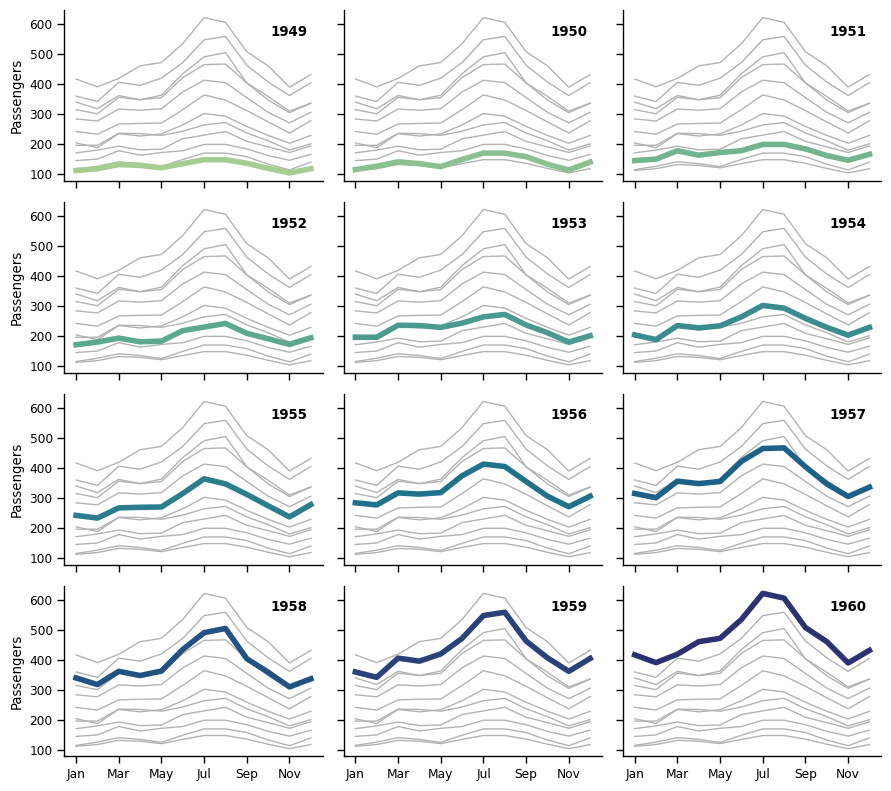

In [19]:
sns.set_context("paper")
flights = sns.load_dataset("flights")

# Plot each year's time series in its own facet
g = sns.relplot(
    data=flights,
    x="month", y="passengers", col="year", hue="year",
    kind="line", palette="crest", linewidth=4, zorder=5,
    col_wrap=3, height=2, aspect=1.5, legend=False,
)

# Iterate over each subplot to customize further
for year, ax in g.axes_dict.items():

    # Add the title as an annotation within the plot
    ax.text(.8, .85, year, transform=ax.transAxes, fontweight="bold")

    # Plot every year's time series in the background
    sns.lineplot(
        data=flights, x="month", y="passengers", units="year",
        estimator=None, color=".7", linewidth=1, ax=ax,
    )

# Reduce the frequency of the x axis ticks
ax.set_xticks(ax.get_xticks()[::2])

# Tweak the supporting aspects of the plot
g.set_titles("")
g.set_axis_labels("", "Passengers")
g.tight_layout()

In [20]:
# Define the time-dependent double-well potential
def double_well_potential(x, t, A, B, C_t):
    """
    Calculates the potential energy of a particle in a time-dependent double-well potential.

    Args:
        x (float): Position of the particle.
        t (float): Current time.
        A (float): Coefficient for the x^4 term.
        B (float): Coefficient for the x^2 term.
        C_t (function): A function that returns the time-dependent bias.

    Returns:
        float: Potential energy at position x and time t.
    """
    bias = C_t(t)
    return A * x**4 + B * x**2 + bias * x

# Define the force derived from the potential
def force(x, t, A, B, C_t):
    """
    Calculates the force on a particle in a time-dependent double-well potential.
    Force is the negative derivative of the potential with respect to position.

    Args:
        x (float): Position of the particle.
        t (float): Current time.
        A (float): Coefficient for the x^4 term.
        B (float): Coefficient for the x^2 term.
        C_t (function): A function that returns the time-dependent bias.

    Returns:
        float: Force on the particle at position x and time t.
    """
    bias_prime = C_t(t) # Assuming the bias term directly adds to the derivative
    return -(4 * A * x**3 + 2 * B * x + bias_prime)

# Define the differential equations for a particle's motion (e.g., overdamped Langevin dynamics)
def particle_dynamics(state, t, A, B, C_t, gamma):
    """
    Describes the time evolution of a particle's position and velocity
    in a time-dependent double-well potential, considering damping.

    Args:
        state (list): [position, velocity] of the particle.
        t (float): Current time.
        A (float): Coefficient for the x^4 term.
        B (float): Coefficient for the x^2 term.
        C_t (function): A function that returns the time-dependent bias.
        gamma (float): Damping coefficient.

    Returns:
        list: [d(position)/dt, d(velocity)/dt]
    """
    x, v = state
    dxdt = v
    dvdt = force(x, t, A, B, C_t) - gamma * v # Neglecting random noise for simplicity
    return [dxdt, dvdt]

In [21]:
A_coeff = 1.0
B_coeff = -5.0
gamma_damping = 0.5 # Damping coefficient

# Time-dependent bias function (e.g., sinusoidal)
def time_dependent_bias(t):
    return 2.0 * np.sin(0.5 * t)

# Initial conditions
initial_position = -2.0
initial_velocity = 0.0
initial_state = [initial_position, initial_velocity]

# Time points for simulation
time_points = np.linspace(0, 20, 500)

# Solve the differential equations
solution = odeint(particle_dynamics, initial_state, time_points, args=(A_coeff, B_coeff, time_dependent_bias, gamma_damping))

# Extract position and velocity
positions = solution[:, 0]
velocities = solution[:, 1]



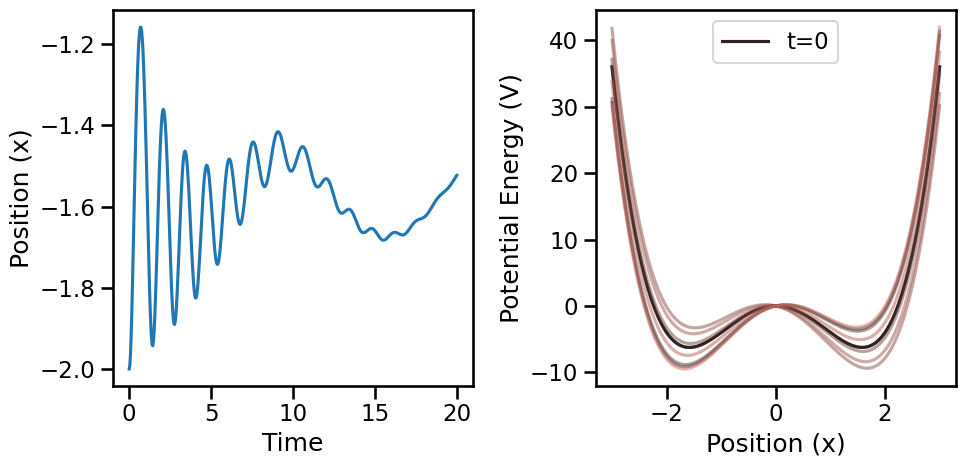

In [22]:
sns.set_context("talk")

fig, ax = plt.subplots(1,2,figsize=(10,5))
# # Plot the particle's trajectory

ax[0].plot(time_points, positions)
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Position (x)")

x_values = np.linspace(-3, 3, 200)

# Create a pandas DataFrame for the solution
solution_df = pd.DataFrame({'Position': x_values})

# Calculate potential energy for 10 different time values and store as columns
time_snapshots = np.linspace(0, 20, 10) # Choose 10 time points
for i, t_snap in enumerate(time_snapshots):
    potential_values = [double_well_potential(x, t_snap, A_coeff, B_coeff, time_dependent_bias) for x in x_values]
    solution_df[f't_{i}'] = potential_values[:len(solution_df)] # Ensure lengths match by slicing if necessary

color = sns.color_palette("dark:salmon",10)

sns.lineplot(data=solution_df, x="Position", y="t_0", color=color[0], ax=ax[1], label="t=0")
for i, t_snap in enumerate(time_snapshots[2:]):
    sns.lineplot(data=solution_df, x="Position", y=f't_{i}', color=color[i], alpha = 0.5, ax=ax[1], label="")

ax[1].set_xlabel("Position (x)")
ax[1].set_ylabel("Potential Energy (V)")


fig.tight_layout()
plt.show()

In [73]:
def plot_time_ridgelines(solution_df, xcol="Position", t_prefix="t_", t_order_up = True,
                         normalize="zscore", offset=1.8, palette=sns.color_palette("rocket"), fill = True):
    # Gather time columns in order t_0, t_1, ...
    tcols = sorted([c for c in solution_df.columns if c.startswith(t_prefix)],
                   key=lambda c: int(re.search(rf"{t_prefix}(\d+)", c).group(1)),
                   reverse=not t_order_up) # Add reverse based on t_order_up flag

    times = [re.search(rf"{t_prefix}(\d+)", c).group(1) for c in tcols]

    # Build long arrays
    x = solution_df[xcol].to_numpy()
    curves = []
    for c in tcols:
        y = solution_df[c].to_numpy(dtype=float)
        if normalize == "zscore":
            y = (y - y.mean()) / (y.std(ddof=0) + 1e-12)
        elif normalize == "minmax":
            span = (np.ptp(y) + 1e-12)
            y = (y - y.min()) / span
            y = (y - 0.5) * 2  # map to ~[-1,1] to keep offsets simple
        elif normalize == "none":
            pass
        curves.append(y)

    # Choose an amplitude-aware default offset if using raw values
    if normalize == "none":
        amp = np.nanpercentile([np.max(np.abs(y)) for y in curves], 95)
        offset = 1.2 * amp if offset is None else offset

      
    fig, ax = plt.subplots()
    for i, (y, t, color) in enumerate(zip(curves, times, palette)):
        y0 = i * offset
        if fill:
            # Fill only when y is less than 0
            ax.fill_between(x, y0, y0 + y, where=(y < 0), alpha=0.45, facecolor=color, edgecolor="none", zorder=1)
        ax.plot(x, y0 + y, lw=2, color=color, zorder=2)
        # baseline
        ax.hlines(y0, x.min(), x.max(), lw=0.8, ls=":", alpha=0.5, zorder=0)
        # # label on left
        ax.text(x.min()+1.25, y0-0.35,
                f"t={t}", ha="left", va="center", fontsize=9,color=color, weight="bold")

    ax.set_xlabel("Position")
    ax.set_yticks([])
    ax.set_ylabel("Time step")
    ax.set_xlim(x.min(), x.max())
    # pad top/bottom so first/last ridge aren’t clipped
    ax.set_ylim(y.min(), (len(curves)//2+1)*offset)
    #sns.despine(left=False, bottom=False)
    plt.tight_layout()
    return fig, ax

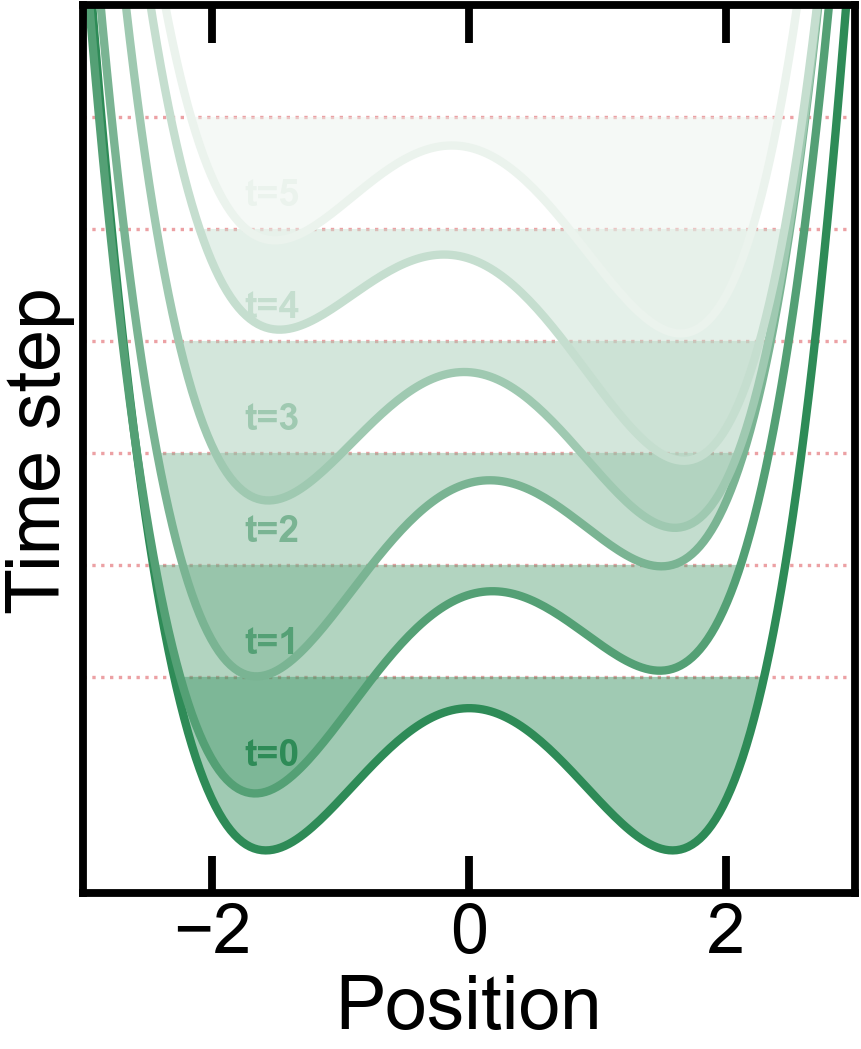

In [74]:
sns.set_context("talk")
fig, ax = plot_time_ridgelines(solution_df,
                               xcol="Position", t_prefix="t_", palette = sns.light_palette("seagreen", reverse=True),
                               fill = True, normalize="zscore", offset=0.5)

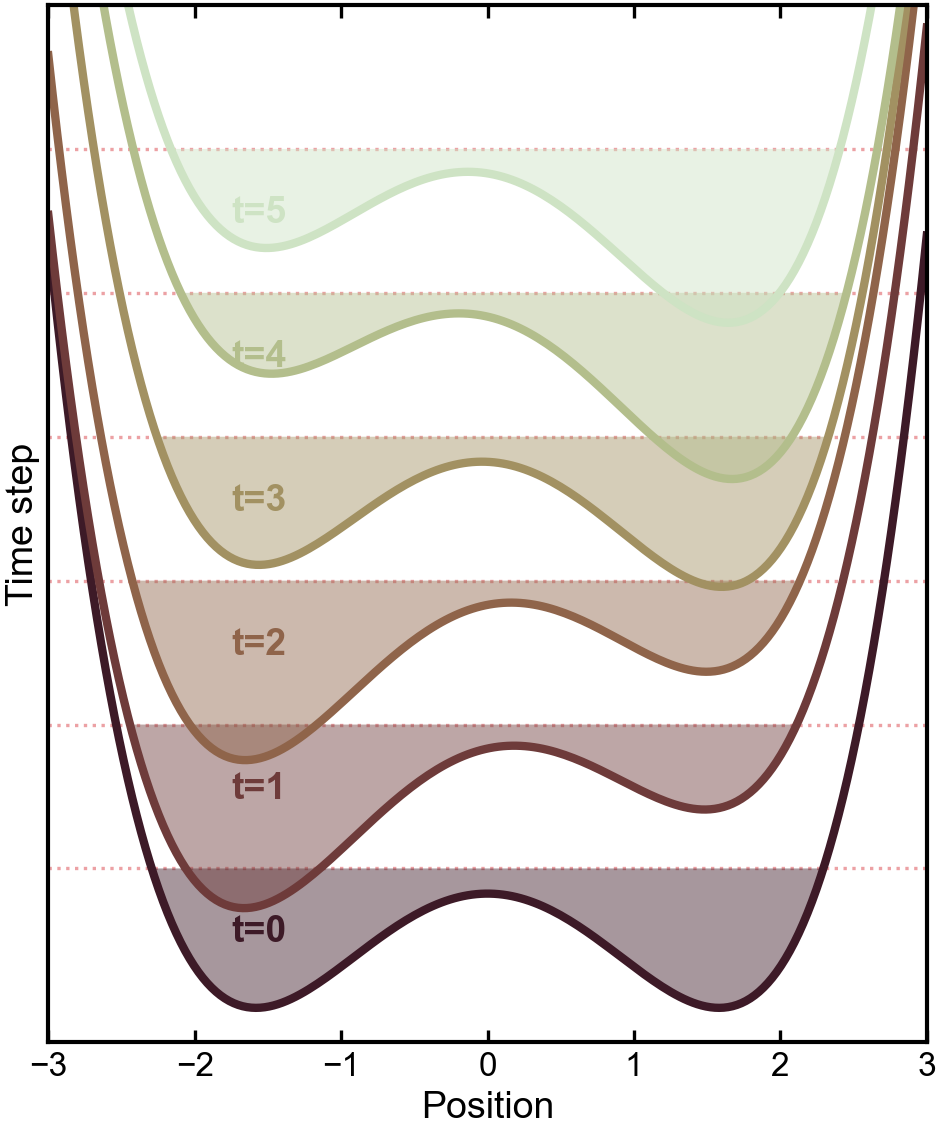

In [75]:
style_file = "../src/style_files/aip.mplstyle"
plt.style.use(style_file)

mypalette = sns.cubehelix_palette(start=.5, rot=.5, reverse = True)
fig, ax = plot_time_ridgelines(solution_df,
                               xcol="Position", t_prefix="t_", palette = mypalette,
                               fill = True, normalize="zscore", offset=0.8)